In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
#from keras.utils import to_categorical

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pandas as pd
import IPython.display as display
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import os,random
import matplotlib.pyplot as plt
from matplotlib import*
import matplotlib
from matplotlib.pyplot import *
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D,AveragePooling2D
#from keras.layers.normalization import BatchNormalization
from keras.callbacks import LearningRateScheduler,ReduceLROnPlateau
#from keras.optimizers import Adam # I believe this is better optimizer for our case
from keras.preprocessing.image import ImageDataGenerator # to augmenting our images for increasing accuracy
from keras.utils.vis_utils import plot_model
import scipy
from sklearn.model_selection import train_test_split # to split our train data into train and validation sets
import numpy as np # linear algebra
import pandas as pd
import IPython.display as display
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import os,random
import matplotlib.pyplot as plt
from matplotlib import*
import matplotlib
from matplotlib.pyplot import *
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import pandas as pd
print(tf.__version__)

2.6.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir = os.path.join(os.path.dirname(zip_file), '/content/drive/MyDrive/Face/Face')
train_dir = os.path.join(data_dir, '/content/drive/MyDrive/Face/Face/train')
test_dir = os.path.join(data_dir, '/content/drive/MyDrive/Face/Face/test')


In [ ]:
import time
import os
from os.path import exists

def count(dir, counter=0):
    "returns number of files in dir and subdirs"
    for pack in os.walk(dir):
        for f in pack[2]:
            counter += 1
    return dir + " : " + str(counter) + "files"


In [ ]:
print('total images for training :', count(train_dir))
print('total images for test :', count(test_dir))


total images for training : /content/drive/MyDrive/Face/Face/train : 2600files
total images for test : /content/drive/MyDrive/Face/Face/test : 2341files


In [ ]:
batch_size = 32
img_height = 180
img_width = 180

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="training",
  #label_mode='binary',
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 4941 files belonging to 2 classes.
Using 3459 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="validation",
  #label_mode='binary',
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 4941 files belonging to 2 classes.
Using 1482 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['test', 'train']


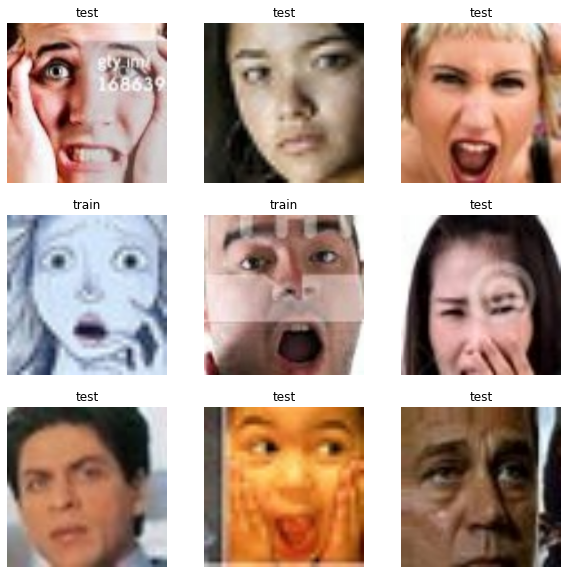

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)


  break

(32, 180, 180, 3)
(32,)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
normalization_layer = layers.experimental.preprocessing.Rescaling(1./255)

In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.00060373597 0.97835004


In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal",
                                                 input_shape=(img_height,
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

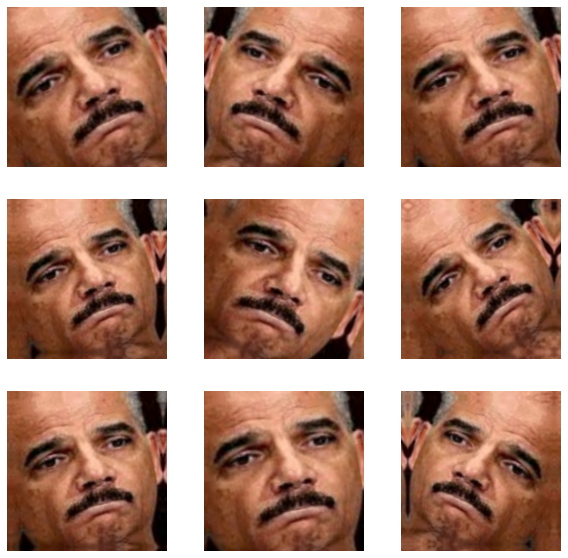

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
def Mynew_CNNmodel():

  model = tf.keras.models.Sequential()
  model.add(layers.Conv2D(8, (3, 3), padding='same',activation='relu', input_shape=(img_height, img_width, 3)))
  model.add(layers.MaxPooling2D(pool_size=(2,2)))
  model.add(layers.BatchNormalization())
  model.add(layers.Dropout(0.2))
  model.add(layers.Conv2D(32, (3, 3), padding='same',activation='relu'))
  model.add(layers.MaxPooling2D(pool_size=(2,2)))

  model.add(layers.Dropout(0.2))

  model.add(layers.Flatten())

  model.add(layers.Dense(512, activation='relu'))
  model.add(layers.Dense(1, activation='sigmoid'))

  opt=tf.keras.optimizers.Adam(0.001)
  model.compile(optimizer=opt,
              loss='binary_crossentropy', # loss='categorical_crossentropy' if softmax
              metrics=['accuracy',tf.keras.metrics.AUC(
    num_thresholds=200,
    curve="ROC",
    summation_method="interpolation",
    name=None,
    dtype=None,
    thresholds=None,
    multi_label=False,
    label_weights=None,
),tf.keras.metrics.Precision(
    thresholds=None, top_k=None, class_id=None, name=None, dtype=None
),tf.keras.metrics.Recall(
    thresholds=None, top_k=None, class_id=None, name=None, dtype=None
),tf.keras.metrics.TruePositives(thresholds=None, name=None, dtype=None),tf.keras.metrics.TrueNegatives(thresholds=None, name=None, dtype=None),tf.keras.metrics.FalsePositives(thresholds=None, name=None, dtype=None),tf.keras.metrics.FalseNegatives(thresholds=None, name=None, dtype=None)])

  return model

In [ ]:
model=Mynew_CNNmodel()
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 180, 180, 8)       224       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 90, 90, 8)         0         
_________________________________________________________________
batch_normalization (BatchNo (None, 90, 90, 8)         32        
_________________________________________________________________
dropout (Dropout)            (None, 90, 90, 8)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 90, 90, 32)        2336      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 45, 45, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 45, 45, 32)       

In [ ]:
new_model=Mynew_CNNmodel()
new_hist=new_model.fit(train_ds,epochs=50,validation_data=val_ds)

Epoch 1/50
109/109 [==============================] - 434s 4s/step - loss: 2.7449 - accuracy: 0.5030 - auc_1: 0.5043 - precision_1: 0.5273 - recall_1: 0.5201 - true_positives_1: 945.0000 - true_negatives_1: 795.0000 - false_positives_1: 847.0000 - false_negatives_1: 872.0000 - val_loss: 0.8706 - val_accuracy: 0.4919 - val_auc_1: 0.5173 - val_precision_1: 0.5514 - val_recall_1: 0.2056 - val_true_positives_1: 161.0000 - val_true_negatives_1: 568.0000 - val_false_positives_1: 131.0000 - val_false_negatives_1: 622.0000
Epoch 2/50
109/109 [==============================] - 6s 55ms/step - loss: 0.8025 - accuracy: 0.5690 - auc_1: 0.6002 - precision_1: 0.5887 - recall_1: 0.5955 - true_positives_1: 1082.0000 - true_negatives_1: 886.0000 - false_positives_1: 756.0000 - false_negatives_1: 735.0000 - val_loss: 0.7499 - val_accuracy: 0.5101 - val_auc_1: 0.5084 - val_precision_1: 0.5399 - val_recall_1: 0.4930 - val_true_positives_1: 386.0000 - val_true_negatives_1: 370.0000 - val_false_positives_1: 